## EDA Reference — Customer Churn Classification

### Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [19]:
train_df = pd.read_csv ("../data/churn_train.csv")
test_df = pd.read_csv ("../data/churn_test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (440833, 12)
Test shape:  (64374, 12)


### Data Types & Info

In [20]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [21]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [22]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


### Check Missing Values & Duplicates

In [23]:
# Missing value 

missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2) 

missing_report = pd.DataFrame({"Missing": missing, "Percent (%)": missing_pct})
print(missing_report[missing_report["Missing"] > 0] if missing.sum() > 0 else "No missing value")

                   Missing  Percent (%)
CustomerID               1          0.0
Age                      1          0.0
Gender                   1          0.0
Tenure                   1          0.0
Usage Frequency          1          0.0
Support Calls            1          0.0
Payment Delay            1          0.0
Subscription Type        1          0.0
Contract Length          1          0.0
Total Spend              1          0.0
Last Interaction         1          0.0
Churn                    1          0.0


In [24]:
# Duplicates
dup_count = train_df.duplicated().sum()
print("Duplicates: ", dup_count)

Duplicates:  0


In [25]:
# Xem dòng bị missing
null_rows = train_df[train_df.isnull().any(axis=1)]
print(f"Số dòng bị missing: {len(null_rows)}")
print(f"Index: {null_rows.index.tolist()}")
null_rows

Số dòng bị missing: 1
Index: [199295]


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Churn Distribution (Target Variable)

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


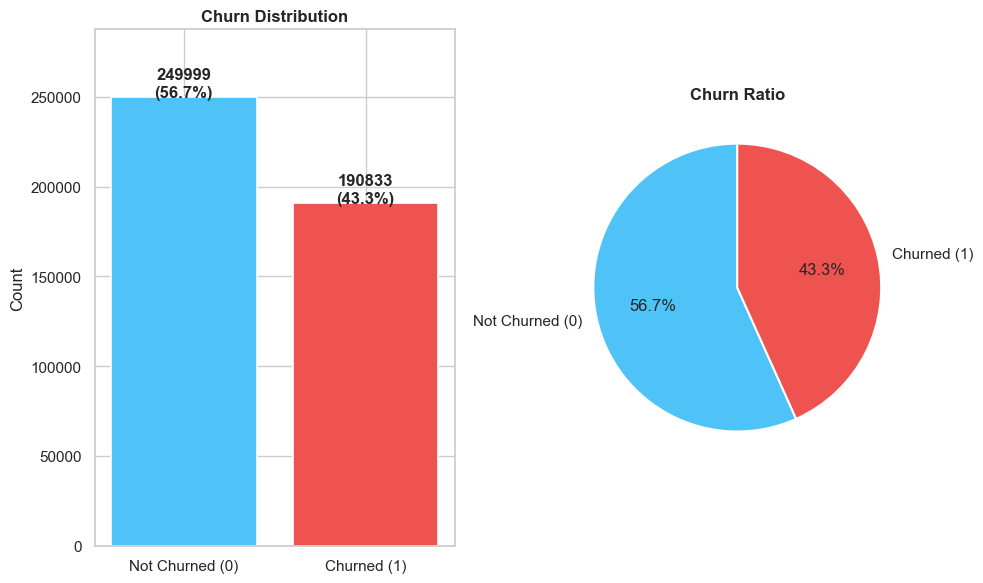

In [26]:
churn_counts = train_df["Churn"].value_counts()
churn_pct = train_df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
colors = ["#4FC3F7", "#EF5350"]
labels = ["Not Churned (0)", "Churned (1)"]

# Bar Chart 
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor="white", linewidth=1.2)
for i, (cnt, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, cnt + 100, f"{cnt}\n({pct:.1f}%)", ha="center", fontweight="bold")
    
axes[0].set_title("Churn Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].margins(y=0.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Churn Ratio", fontweight="bold")
plt.tight_layout()
plt.show()


### Numerical Feature Distributions

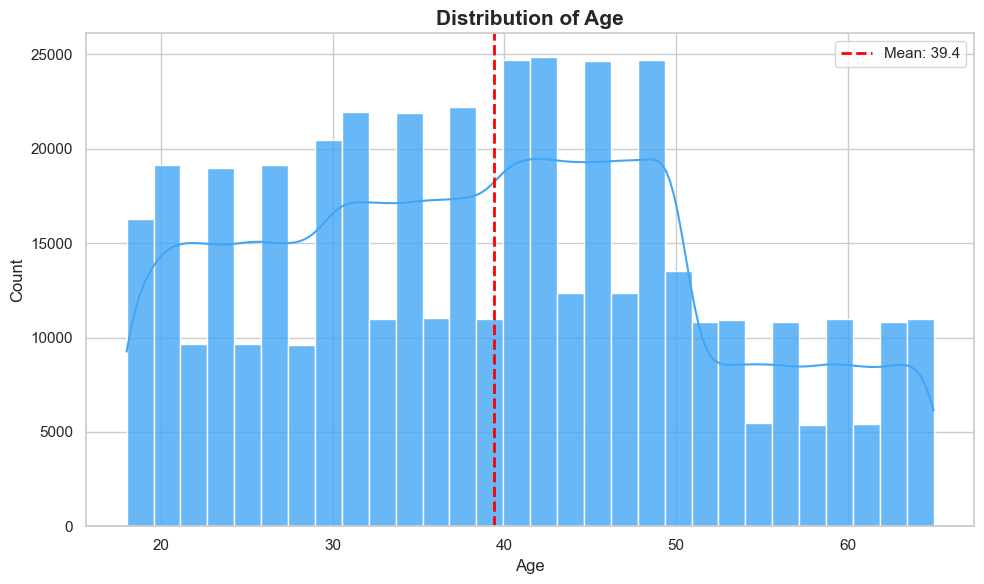

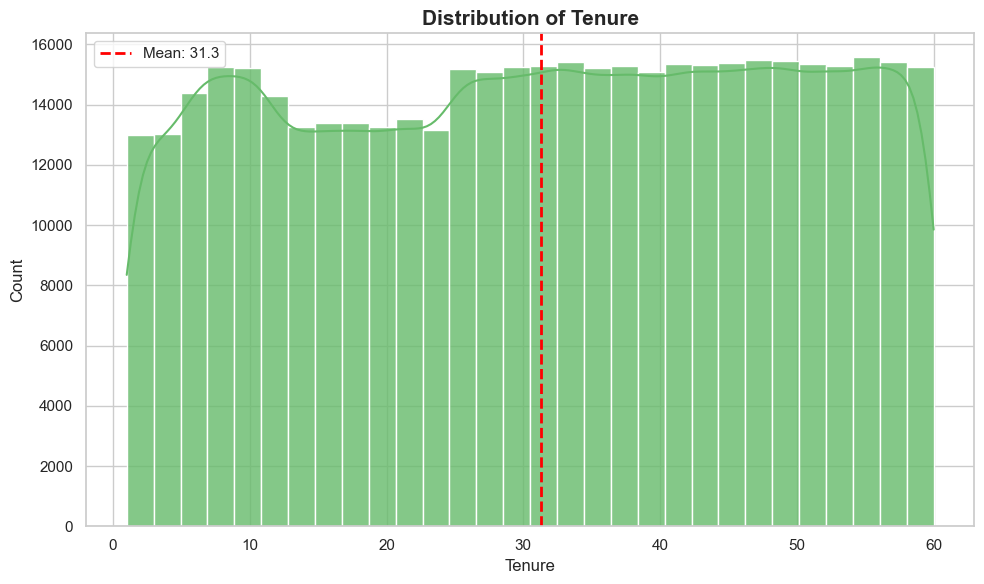

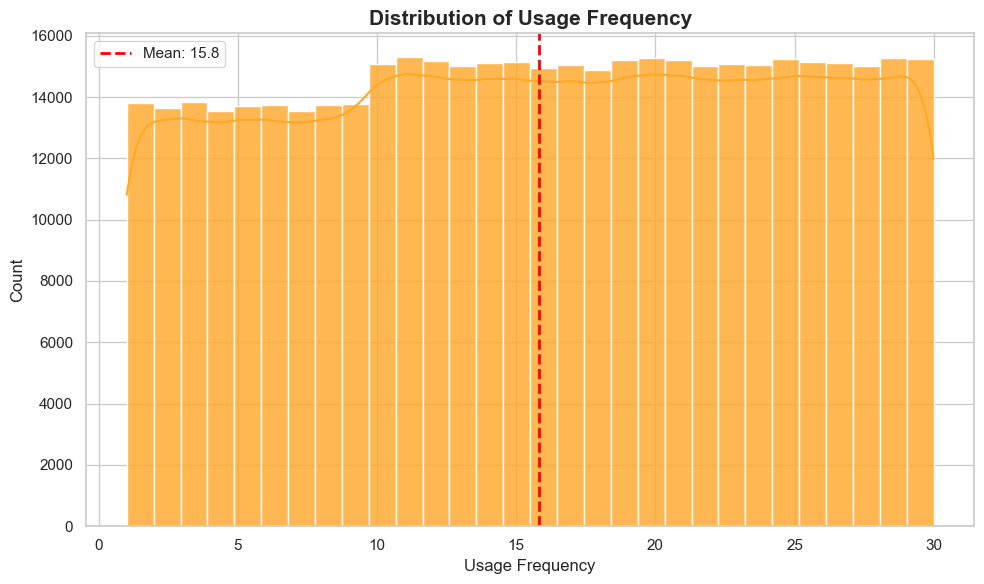

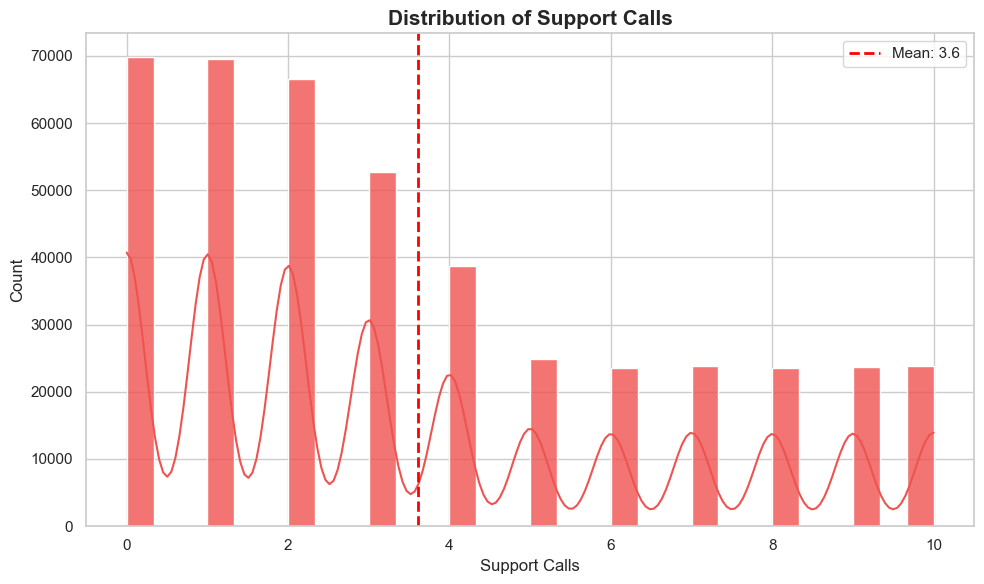

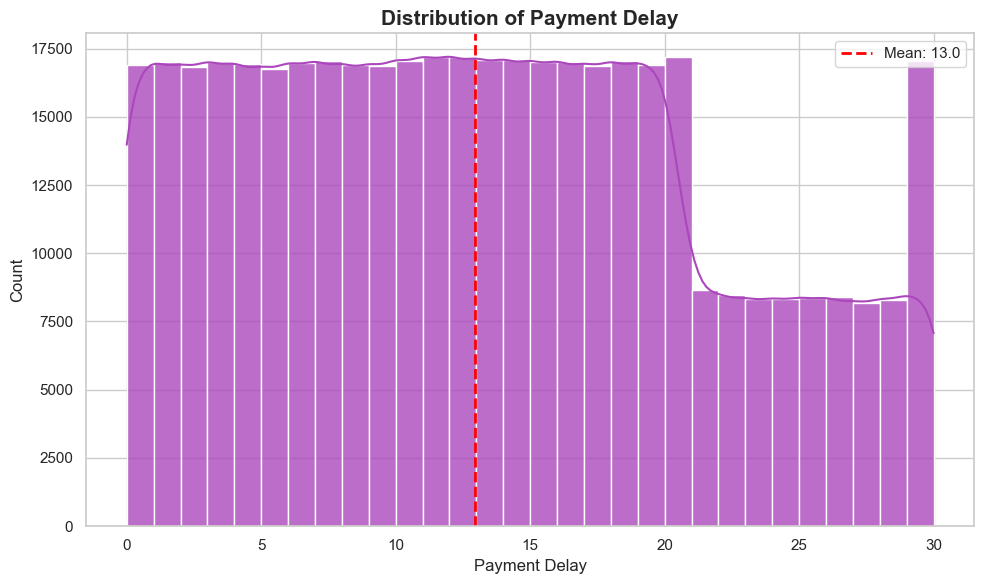

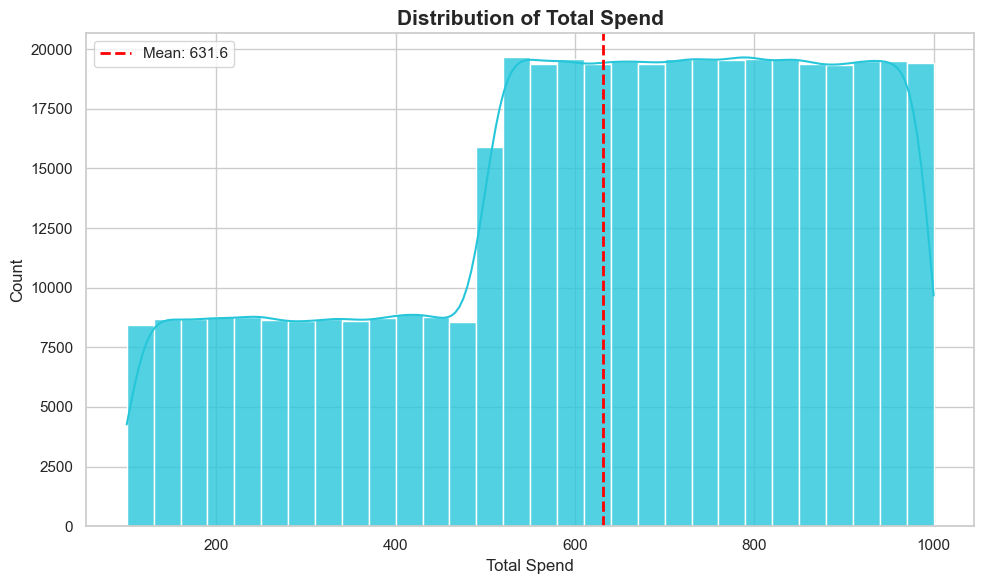

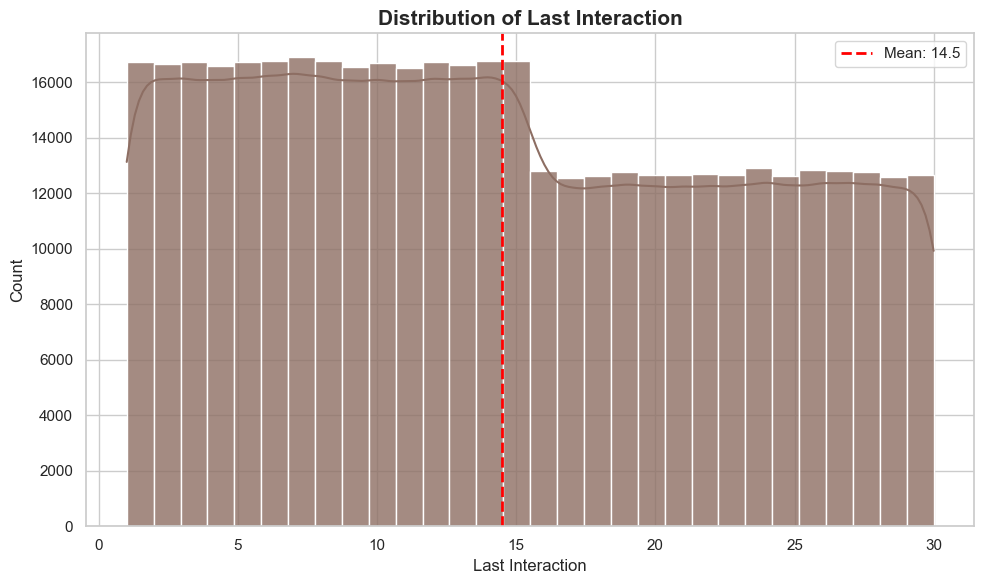

In [27]:
num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls",
            "Payment Delay", "Total Spend", "Last Interaction"]
colors = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350",
          "#AB47BC", "#26C6DA", "#8D6E63"]

sns.set_theme(style="whitegrid")

for i, col in enumerate(num_cols):
    plt.figure(figsize=(10, 6))
    
    sns.histplot(train_df[col].dropna(), bins=30, color=colors[i], 
                 edgecolor="white", alpha=0.8, kde=True)

    mean_val = train_df[col].mean()
    plt.axvline(mean_val, color="red", linestyle="--", 
                linewidth=2, label=f"Mean: {mean_val:.1f}")
    
    plt.title(f"Distribution of {col}", fontweight="bold", fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Categorical Feature Distributions


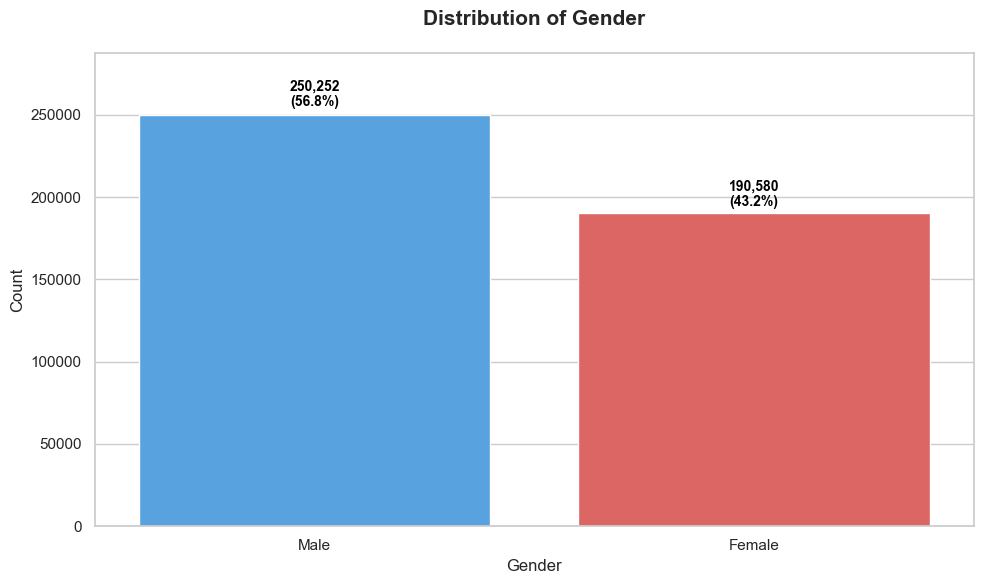

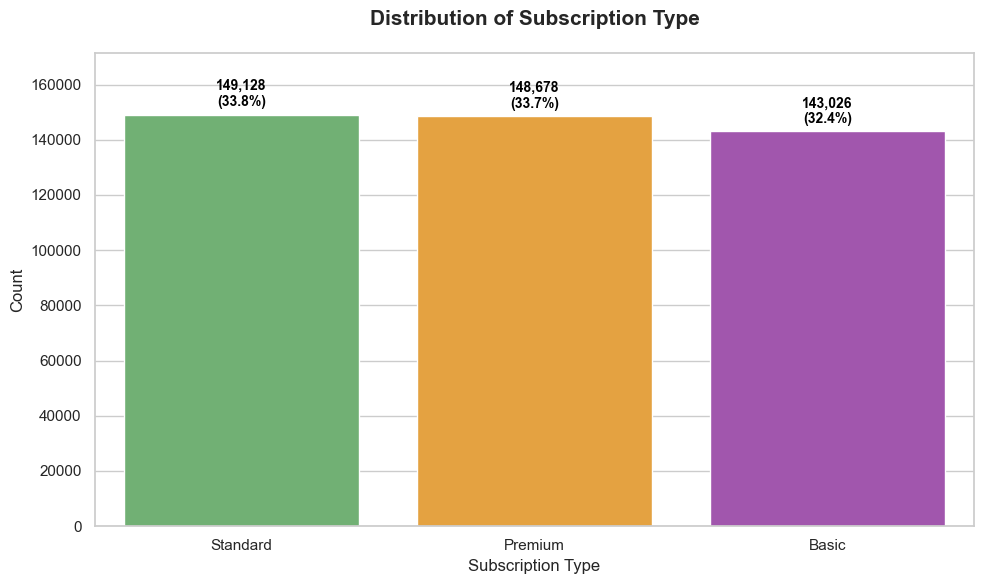

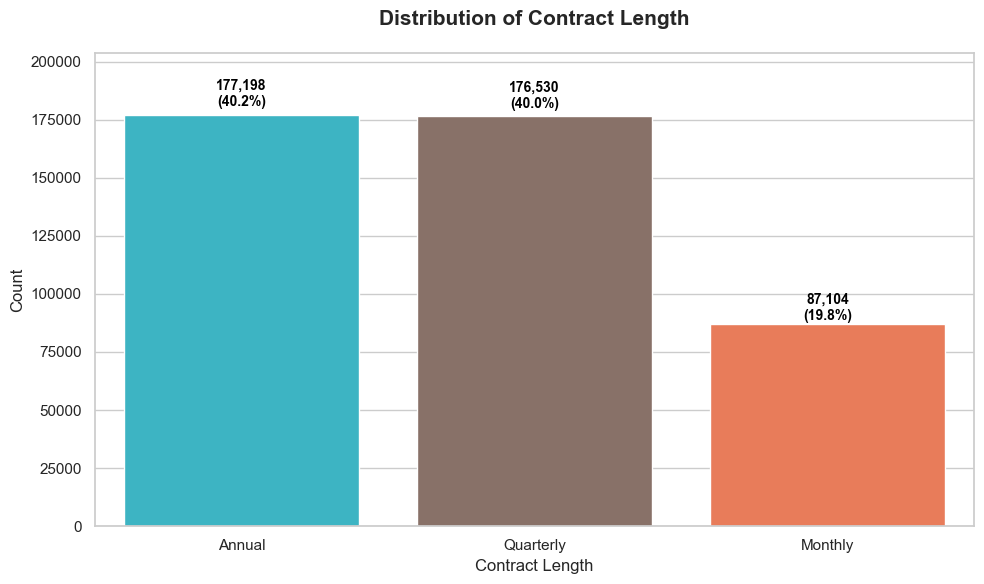

In [28]:
cat_cols = ["Gender", "Subscription Type", "Contract Length"]
cat_colors = [["#42A5F5", "#EF5350"],
              ["#66BB6A", "#FFA726", "#AB47BC"],
              ["#26C6DA", "#8D6E63", "#FF7043"]]

sns.set_theme(style="whitegrid")

for i, col in enumerate(cat_cols):
    plt.figure(figsize=(10, 6))
    
    counts = train_df[col].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    
    ax = sns.barplot(x=counts.index.astype(str), y=counts.values, 
                     palette=cat_colors[i], hue=counts.index.astype(str), legend=False)
    
    for j, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
        ax.text(j, cnt + (cnt * 0.02), f"{cnt:,}\n({pct}%)", 
                ha="center", fontweight="bold", fontsize=10, color="black")
    

    plt.title(f"Distribution of {col}", fontweight="bold", fontsize=15, pad=20)
    plt.ylabel("Count", fontsize=12)
    plt.xlabel(col, fontsize=12)
    
    plt.ylim(0, counts.max() * 1.15) 
    
    plt.tight_layout()
    plt.show()

### Numerical Features vs Churn 

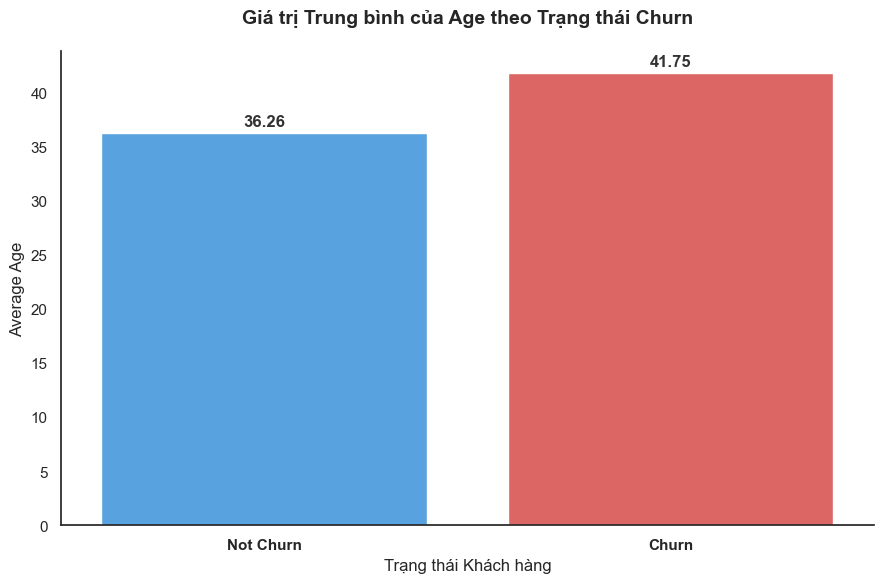

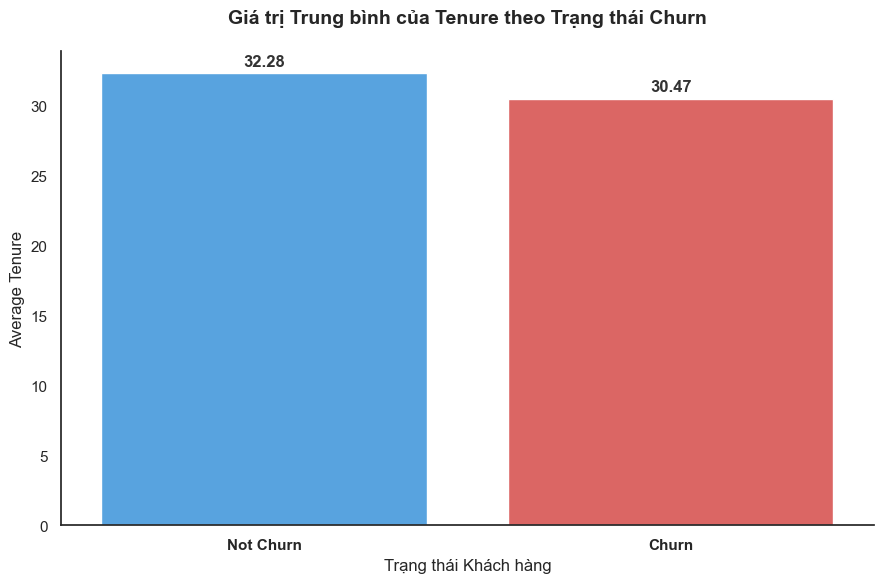

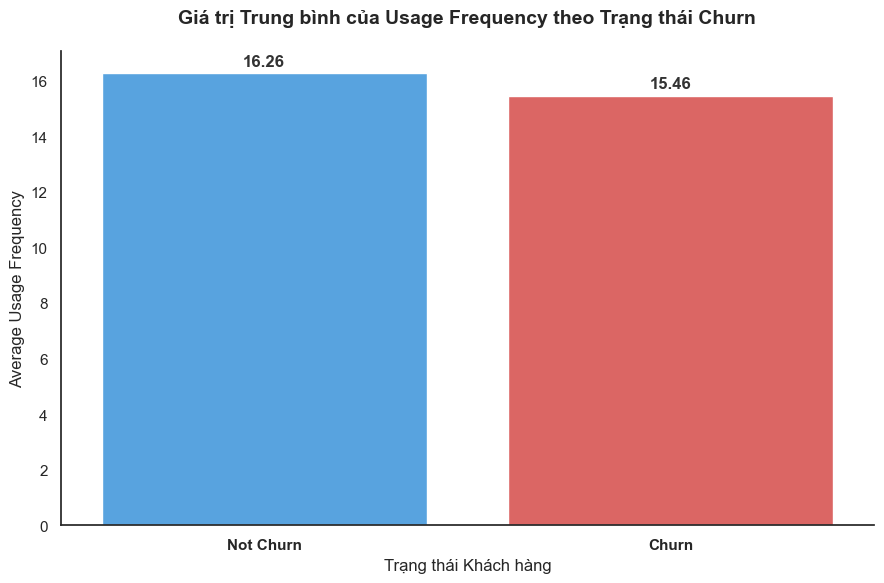

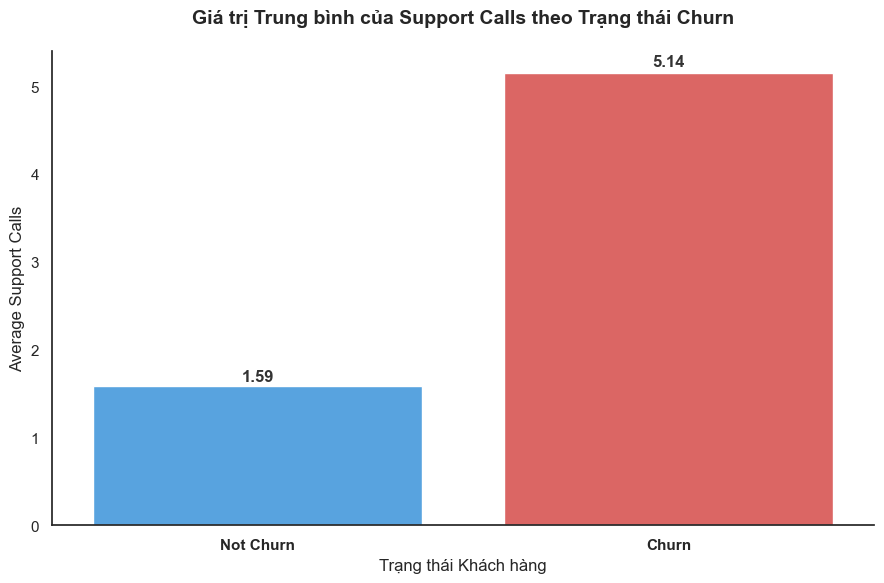

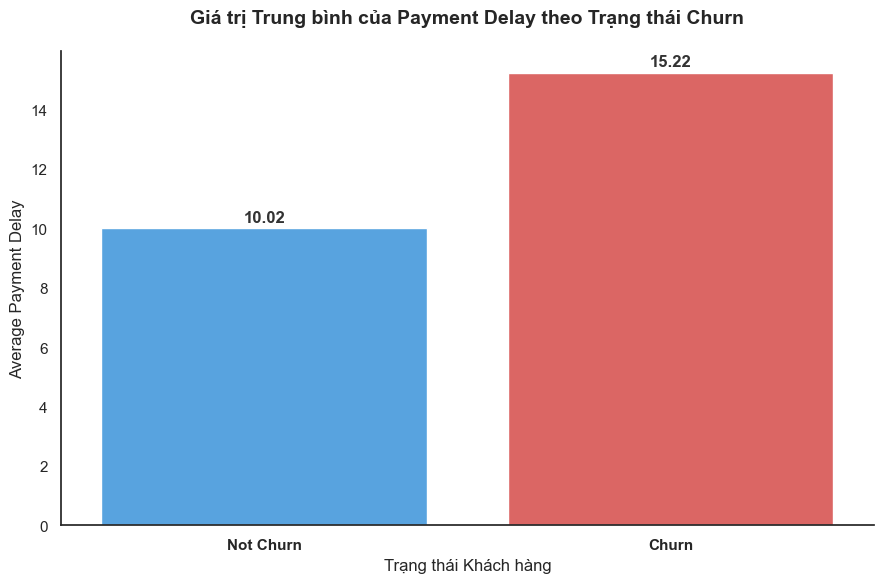

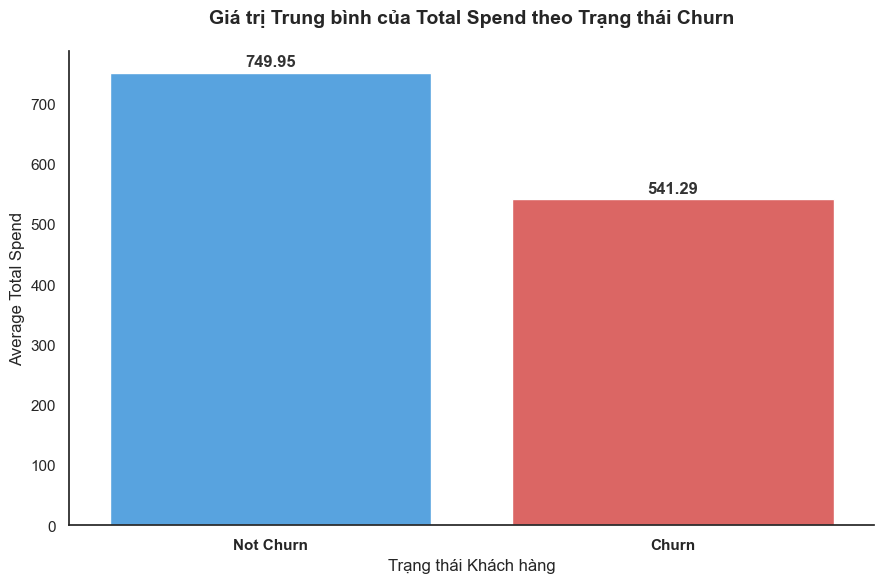

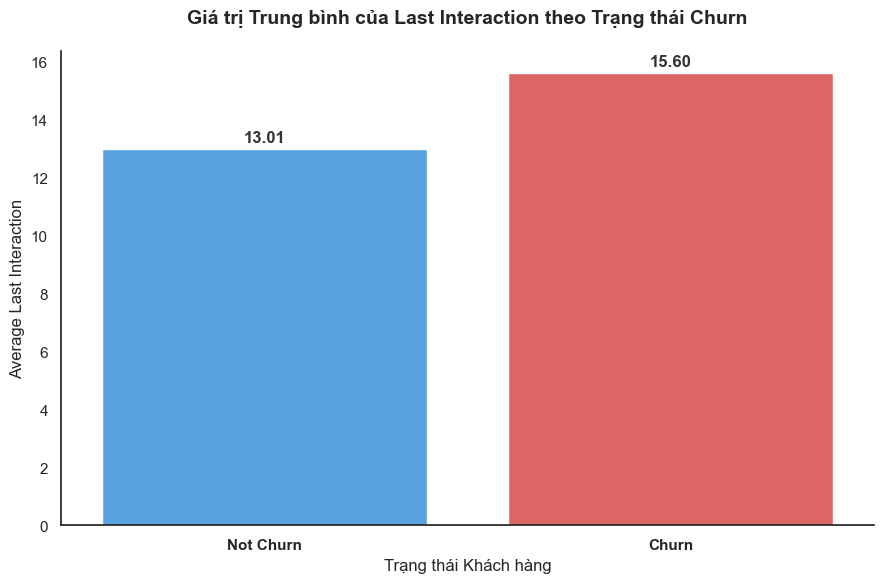

In [29]:
bar_colors = ["#42A5F5", "#EF5350"]

sns.set_theme(style="white")

for col in num_cols:
    plt.figure(figsize=(9, 6))
    
    ax = sns.barplot(x="Churn", y=col, data=train_df, 
                     palette=bar_colors, hue="Churn", legend=False,
                     errorbar=None)

    means = train_df.groupby("Churn")[col].mean()
    
    for i, m in enumerate(means):
        ax.text(i, m + (m * 0.01), f"{m:.2f}", 
                ha='center', va='bottom', fontweight='bold', 
                fontsize=12, color="#333333")
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Churn", "Churn"], fontweight="bold", fontsize=11)
    
    plt.title(f"Giá trị Trung bình của {col} theo Trạng thái Churn", 
              fontweight="bold", fontsize=14, pad=20)
    plt.xlabel("Trạng thái Khách hàng", fontsize=12)
    plt.ylabel(f"Average {col}", fontsize=12)
    

    sns.despine()
    
    plt.tight_layout()
    plt.show()
    print("\n")

### Categorical Features vs Churn

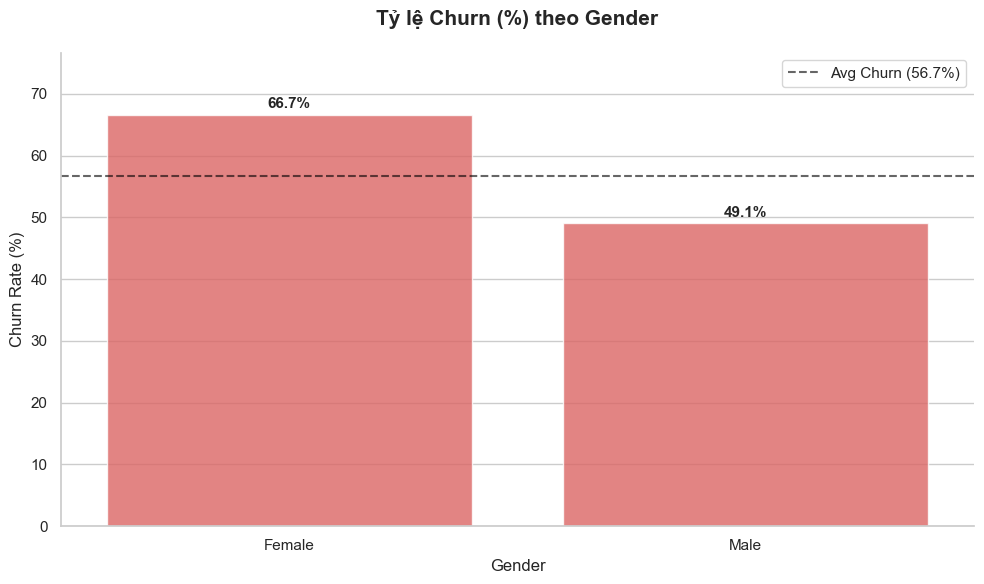

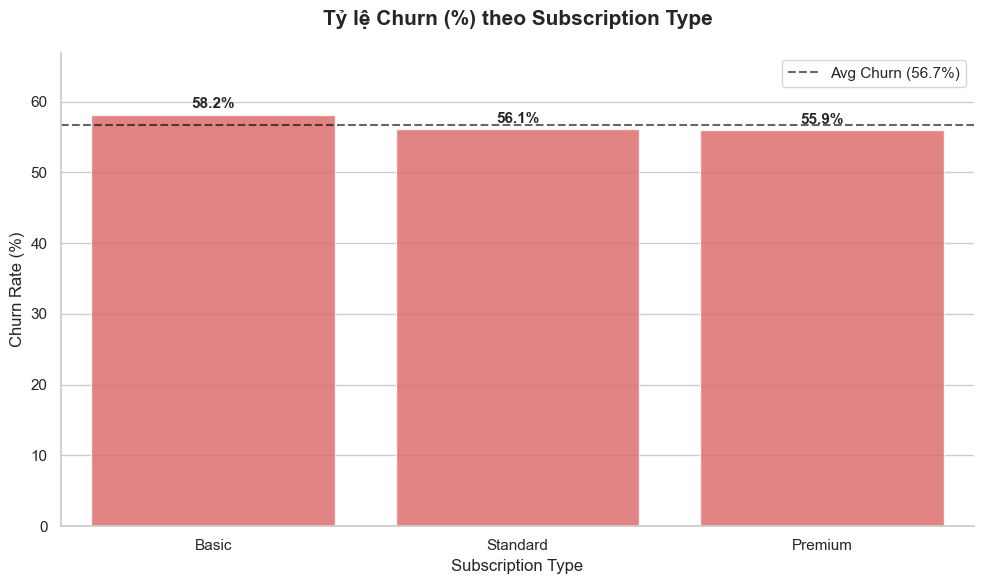

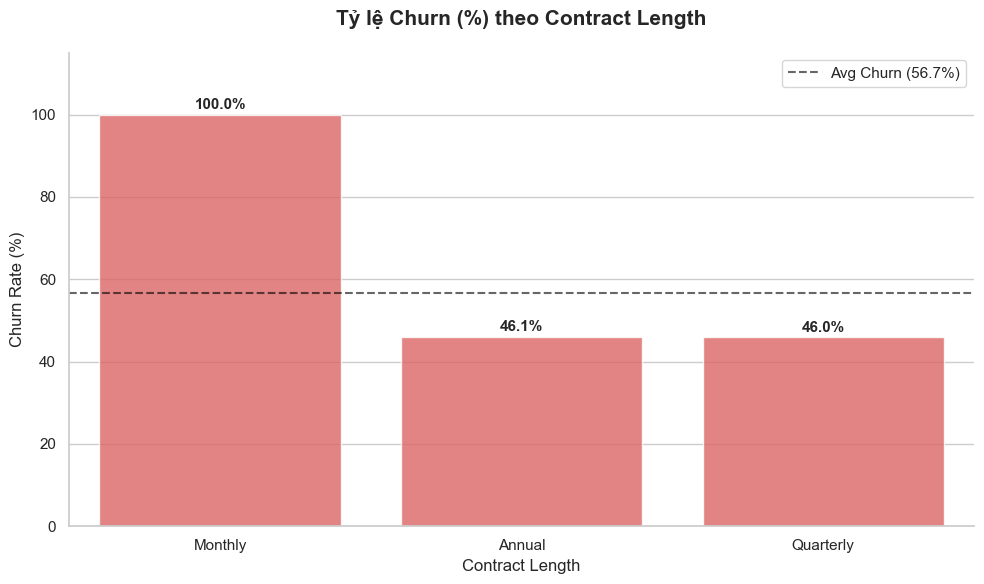

In [30]:
churn_color = "#EF5350"
avg_churn_rate = train_df["Churn"].mean() * 100

sns.set_theme(style="whitegrid")

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    
    churn_rates = train_df.groupby(col)["Churn"].mean() * 100
    churn_rates = churn_rates.sort_values(ascending=False)
    
    ax = sns.barplot(x=churn_rates.index.astype(str), y=churn_rates.values, 
                     color=churn_color, alpha=0.8)
    
    plt.axhline(avg_churn_rate, color="black", linestyle="--", alpha=0.6, 
                label=f"Avg Churn ({avg_churn_rate:.1f}%)")
    
    for j, rate in enumerate(churn_rates.values):
        ax.text(j, rate + 0.5, f"{rate:.1f}%", 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.title(f"Tỷ lệ Churn (%) theo {col}", fontweight="bold", fontsize=15, pad=20)
    plt.ylabel("Churn Rate (%)", fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylim(0, max(churn_rates.values) * 1.15)
    plt.legend()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

### EDA Summary

| Insight | Chi tiết |
|---------|----------|
| Dataset size | Train: 440,832 × 12 (sau khi drop 1 missing) |
| Missing | 1 dòng (index 199295) → drop |
| Duplicates | 0 |
| Class balance | Churn=1: 56.7% / Churn=0: 43.3% → hơi imbalanced |
| Top features | Support Calls (+0.29), Payment Delay (+0.19) |
| Multicollinearity | Không có |
| Gender | Gần như không ảnh hưởng đến Churn |
| Contract Monthly | Churn rate cao nhất (~62%) |
| Subscription Basic | Churn rate cao nhất (~60%) |